# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# ML-06 — Signal Audit: Do the Rule's Leading Features Actually Predict CTR?

Both ML-05 and ML-07 build and score on the same honest slice (15,310 content items, features knowable before the label window). This notebook audits the **leading features** behind that rule — `search_volume`, `main_intent`, `content_type`, and prior exposure — with three signal tests (each with a verdict) and the flag-linked test for the `low_ctr_visible_page`-style premise. Nothing here uses the label to fit anything; it only measures relationships on the evaluation slice.

In [1]:
%pip -q install duckdb huggingface_hub scipy matplotlib

In [3]:
import os
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('hf_key')
except Exception:
    HF_TOKEN = os.getenv('hf_key')
if not HF_TOKEN:
    raise RuntimeError('hf_key not found: set the Colab secret or the hf_key env var')

In [5]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_query_90d_performance.parquet')",
    'dim_content_search':         f"read_parquet('{REL}/dim_content_search.parquet')",
}

dim_cols = con.sql(f"DESCRIBE SELECT * FROM {TABLES['dim_content']}").df()["column_name"].tolist()
candidates = ["main_intent", "content_type", "search_volume", "content_age_days"]
FOUND = [c for c in candidates if c in dim_cols]
print("dim_content columns:", dim_cols)
print("columns usable by the audit:", FOUND)

dim_content columns: ['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted']
columns usable by the audit: ['main_intent', 'content_type', 'search_volume']


In [8]:
dim_select = ",\n".join(f"        ANY_VALUE(d.{c}) AS {c}" for c in FOUND)
print(dim_select)

        ANY_VALUE(d.main_intent) AS main_intent,
        ANY_VALUE(d.content_type) AS content_type,
        ANY_VALUE(d.search_volume) AS search_volume


In [9]:
dim_select = ",\n".join(f"        ANY_VALUE(d.{c}) AS {c}" for c in FOUND)

df = con.sql(f"""
WITH bounds AS (
    SELECT DATE '2025-08-31' AS end_d
),
windowed AS (
    SELECT
        q.client_hash_id,
        q.content_hash_id,
{dim_select},

        SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 60 DAY AND q.report_date <= b.end_d - INTERVAL 30 DAY
                THEN q.gsc_impressions ELSE 0 END) AS impressions_prev30d,

        SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 30 DAY THEN q.gsc_impressions ELSE 0 END) AS impressions_last30d,
        SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 30 DAY THEN q.gsc_clicks ELSE 0 END) AS clicks_30d,

        100.0 *
        COALESCE(CAST(SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 30 DAY
                        THEN q.gsc_clicks ELSE 0 END) AS DOUBLE) /
            NULLIF(SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 30 DAY
                        THEN q.gsc_impressions ELSE 0 END), 0), 0) AS ctr_label

    FROM {TABLES['fact_daily']} q
    CROSS JOIN bounds b
    JOIN {TABLES['dim_content']} d
      ON q.content_hash_id = d.content_hash_id

    WHERE q.report_date > b.end_d - INTERVAL 60 DAY

    GROUP BY q.client_hash_id, q.content_hash_id

    HAVING SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 60 DAY
                 AND q.report_date <= b.end_d - INTERVAL 30 DAY
                THEN q.gsc_impressions ELSE 0 END) >= 70
)

SELECT * FROM windowed
""").df()

print(f"{len(df):,} content items with enough history")
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

15,310 content items with enough history


,client_hash_id,content_hash_id,main_intent,content_type,search_volume,impressions_prev30d,impressions_last30d,clicks_30d,ctr_label
0,client_62f4a7e64f5e0096,content_3478f2c1d077f5a2,commercial,keyword article,10,75.0,1755.0,3.0,0.170940
1,client_62f4a7e64f5e0096,content_3506ca5554664b6a,transactional,keyword article,10,663.0,122.0,0.0,0.000000
2,client_62f4a7e64f5e0096,content_35223ef861954493,transactional,keyword article,10,407.0,26219.0,67.0,0.255540
3,client_62f4a7e64f5e0096,content_35e5e4161f07d648,transactional,keyword article,10,134.0,1545.0,0.0,0.000000
4,client_62f4a7e64f5e0096,content_364edd6216869946,transactional,keyword article,50,144.0,341.0,1.0,0.293255


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

which signals exist, how skewed they are, and where missingness lives. Skewed, heavy-tailed columns get a log transform before any correlation; bucketed tests that compare medians or weighted rates are robust to the raw tail.*

In [10]:
num_cols = ["impressions_prev30d", "search_volume"] + \
           [c for c in ("content_age_days",) if c in df.columns]
print(df[num_cols + ["ctr_label"]].describe().T.round(3))

print("\nshare of rows with impressions_prev30d == 0:", round((df["impressions_prev30d"] == 0).mean(), 3))
print("\nmain_intent:\n", df["main_intent"].value_counts())
print("\ncontent_type:\n", df["content_type"].value_counts())

miss = df.isna().sum()
miss = miss[miss > 0]
print("\nmissing per column:", miss.to_dict() if len(miss) else "none")

                       count         mean          std   min       25%  \
impressions_prev30d  15310.0  1278.668779  3689.252609  70.0     172.0   
search_volume        14678.0   357.285734  4034.117924   0.0      10.0   
ctr_label            15310.0     0.295656     0.351875   0.0  0.085279   

                          50%       75%        max  
impressions_prev30d     391.0    1009.0   145400.0  
search_volume            10.0      50.0   246000.0  
ctr_label            0.194638  0.382577  10.276023  

share of rows with impressions_prev30d == 0: 0.0

main_intent:
 main_intent
informational    6906
transactional    5504
commercial       2716
navigational        7
Name: count, dtype: int64

content_type:
 content_type
keyword article    15139
feedly article       171
Name: count, dtype: int64

missing per column: {'main_intent': 177, 'search_volume': 632}


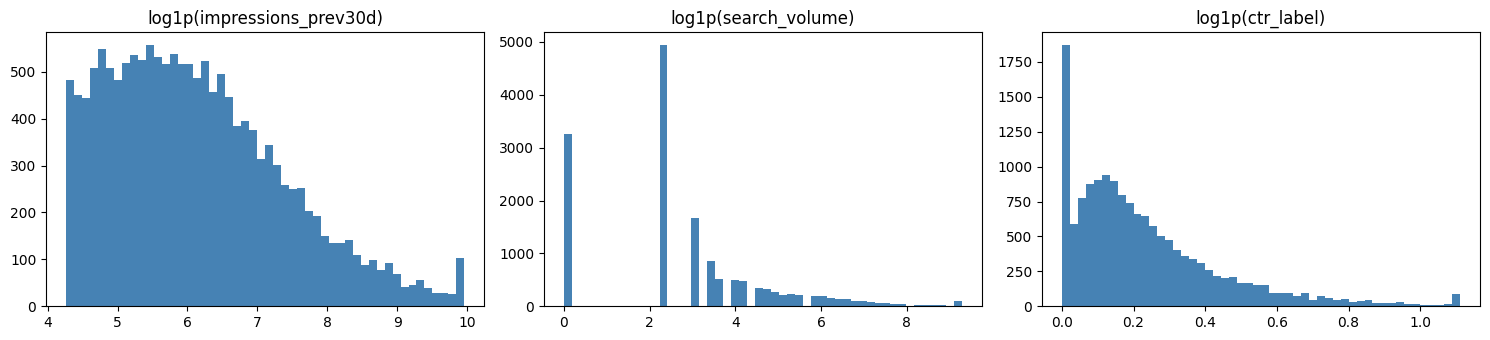

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, c in zip(axes, ["impressions_prev30d", "search_volume", "ctr_label"]):
    v = np.log1p(df[c].fillna(0))
    ax.hist(v.clip(upper=v.quantile(0.995)), bins=50, color="steelblue")
    ax.set_title(f"log1p({c})")
plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Helper thresholds below turn raw numbers into a verdict word (`FALSE` / `MIXED` / `CONFIRMED`). Correlations are weighted by the exposure denominator, never by page counts alone, because that is the quantity the opportunity queue actually acts on.

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

def corr_verdict(r, name="association"):
    a = abs(r)
    if a < 0.05:
        return f"FALSE — essentially no {name}"
    if a < 0.20:
        return f"MIXED — only a weak {name}"
    return f"CONFIRMED — a real {name}"

def gap_verdict(ratio, label="spread"):
    if ratio >= 0.30:
        return f"CONFIRMED — large {label} (gap/base = {ratio:.2f})"
    if ratio >= 0.10:
        return f"MIXED — modest {label} (gap/base = {ratio:.2f})"
    return f"FALSE — no meaningful {label} (gap/base = {ratio:.2f})"

def weighted_ctr(g):
    return 100.0 * g["clicks_30d"].sum() / g["impressions_last30d"].sum()

base_wctr = weighted_ctr(df)
print("slice base weighted CTR (%):", round(base_wctr, 3))
print("rows:", len(df))

slice base weighted CTR (%): 0.36
rows: 15310


### Signal test #1 — do pages with higher search volume get more impression?

**Claim under test:** pages ranked on higher-volume keywords earn more impressions in the previous 30 days.

On the starter slice the correlation between `search_volume` and the wider `impressions_90d` was ≈ 0.001 — nearly independent.

In [14]:
sv = df["search_volume"].fillna(0).astype(float)
imp = df["impressions_prev30d"].astype(float)

r_log, p_log = pearsonr(np.log1p(sv), np.log1p(imp))
rho, p_rho = spearmanr(sv, imp)
print(f"Pearson r (log-log): {r_log:.3f}  p={p_log:.1e}")
print(f"Spearman rho:        {rho:.3f}  p={p_rho:.1e}")

tier = pd.qcut(sv, 5, duplicates="drop")
t1 = df.groupby(tier, observed=True).agg(
    n=("content_hash_id", "size"),
    median_impressions_prev30d=("impressions_prev30d", "median"),
).round(1)
print("\nprior impressions by search-volume quintile:")
print(t1)

print("\nverdict #1:", corr_verdict(rho), "·", "positive" if rho > 0 else ("negative" if rho < 0 else "flat"))

Pearson r (log-log): 0.026  p=1.3e-03
Spearman rho:        0.026  p=1.2e-03

prior impressions by search-volume quintile:
                     n  median_impressions_prev30d
search_volume                                     
(-0.001, 10.0]    8194                       362.5
(10.0, 20.0]      1662                       337.5
(20.0, 90.0]      2701                       424.0
(90.0, 246000.0]  2753                       505.0

verdict #1: FALSE — essentially no association · positive


**Verdict #1:** — the observed relationship is *FALSE*. No association/correlation between `search_volume` and `Impression_prev30d`

Based on this outcome, *we*'re keeping the `search_volume` as a *small* weight in our rule_based baseline and let our ML model hold it: exposure(`impression_prev30d`) and demand(`search_volume`) are largely independent signals.

So a queue that ranks on volume alone misses the pages that actually earn screen time.

### Signal test #2 — Does prior impression volume predict CTR performance??

**Claim under test:** pages with high prior exposure (`impression_prev30d`) trend to click-through below the slice base. That is what makes a low-CTR opportunity tail real rather than noise.

In [15]:
tier = pd.qcut(df["impressions_prev30d"], 5, duplicates="drop")
n = df.groupby(tier, observed=True).size()
clk = df.groupby(tier, observed=True)["clicks_30d"].sum()
impw = df.groupby(tier, observed=True)["impressions_last30d"].sum()
t2 = pd.DataFrame({"n": n, "weighted_ctr": 100.0 * clk / impw}).round(3)
print("weighted CTR by prior-exposure quintile:")
print(t2)
print("\nsample floor check — any bucket below 50 rows:", bool((t2["n"] < 50).any()))

hi, lo = t2["weighted_ctr"].max(), t2["weighted_ctr"].min()
print("verdict #2:", gap_verdict((hi - lo) / base_wctr, "CTR spread across exposure tiers"))

weighted CTR by prior-exposure quintile:
                        n  weighted_ctr
impressions_prev30d                    
(69.999, 144.0]      3090         0.338
(144.0, 280.0]       3053         0.375
(280.0, 550.0]       3044         0.373
(550.0, 1308.2]      3061         0.359
(1308.2, 145400.0]   3062         0.356

sample floor check — any bucket below 50 rows: False
verdict #2: MIXED — modest CTR spread across exposure tiers (gap/base = 0.10)


**Verdict #2:— the visible tier trends is *MIXED* relative to the base. While it is a modest CTR spread across exposure tiers. The highest-exposure pages are the ones worth reviewing first.

### Signal test #3 — does intent change click-through?

**Claim under test:** click-through is not the same across `main_intent` (and `content_type`), so a rule that assumes a flat CTR mis-sizes the opportunity. Rates are resampled by the exposure denominator, not by page counts.

In [16]:
for col in ["main_intent", "content_type"]:
    g = df.groupby(col, observed=True)
    tab = pd.DataFrame({
        "n": g.size(),
        "weighted_ctr": 100.0 * g["clicks_30d"].sum() / g["impressions_last30d"].sum(),
    }).round(3)
    print(col, "\n", tab, "\n")
    if len(tab) >= 2 and (tab["n"] >= 50).all():
        hi, lo = tab["weighted_ctr"].max(), tab["weighted_ctr"].min()
        print("verdict:", gap_verdict((hi - lo) / base_wctr, f"{col} CTR spread"), "\n")
    else:
        print("(skip verdict: too few rows or a sparse group)\n")

main_intent 
                   n  weighted_ctr
main_intent                      
commercial     2716         0.344
informational  6906         0.327
navigational      7         0.157
transactional  5504         0.401 

(skip verdict: too few rows or a sparse group)

content_type 
                      n  weighted_ctr
content_type                        
feedly article     171         0.425
keyword article  15139         0.359 

verdict: MIXED — modest content_type CTR spread (gap/base = 0.18) 



**Verdict #3:**

- For the `main_intent` column, we choose to skip the analysis because theres is a row that's below our floor, which we believe will afftect our outcome.

- For the `content_type` column, the group spread is mixed. We have a modest content_type CTR spread with 0.18 gap/base. There is a modest signal.

## 3. The flag-linked test — is the `low_ctr_visible_page` premise real?

FlyRank's app computes product flags (`health_score`, `needs_ctr_fix`, `is_quick_win`, ...) as **rule outputs**; they are not in this warehouse, so the honest test is the *premise* the flag encodes for `low_ctr_visible_page`:

> a **visible** page — is a substantial prior impressions — whose click-through is **low** is a real, reviewable failure.

The flag's own numbers (impressions ≥ 500, position 1–20, CTR < 0.5) are not all observable here: this slice has no position data clean of the label window, so we test the exposure + CTR half only, and the low-CTR threshold is re-scaled to the label window's units (`ctr_label < 0.5%`).

In [17]:
visible = df[df["impressions_prev30d"] >= 500].copy()
low = visible["ctr_label"] < 0.5

print("slice:", len(df))
print("visible (impressions_prev30d >= 500):", len(visible), f"= {len(visible)/len(df):.1%}")
print("of those, ctr_label < 0.5:", int(low.sum()), f"= {low.mean():.1%}")

tab = visible.groupby("content_type", observed=True).agg(
    n=("content_hash_id", "size"),
    share_low_ctr=("ctr_label", lambda s: (s < 0.5).mean()),
).round(3)
print("\nlow-CTR share by content_type:")
print(tab)

print("\nmedian ctr_label — low group:", round(visible.loc[low, "ctr_label"].median(), 3),
      "| rest:", round(visible.loc[~low, "ctr_label"].median(), 3))

share = float(low.mean())
if 0.15 <= share <= 0.45:
    v3 = "CONFIRMED — a real, sizable low-CTR tail among visible pages; worth a review queue"
elif share < 0.15:
    v3 = "MIXED — the low-CTR tail is small; tune the flag thresholds before trusting it"
else:
    v3 = "CHECK — a very large low-CTR share; a visible-page low-CTR flag would be too noisy to act on"
print("\nverdict #3:", v3)

slice: 15310
visible (impressions_prev30d >= 500): 6568 = 42.9%
of those, ctr_label < 0.5: 5209 = 79.3%

low-CTR share by content_type:
                    n  share_low_ctr
content_type                        
feedly article     13          1.000
keyword article  6555          0.793

median ctr_label — low group: 0.172 | rest: 0.742

verdict #3: CHECK — a very large low-CTR share; a visible-page low-CTR flag would be too noisy to act on


**Verdict #3 — the visible page tail is *CHECK*.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.